<a href="https://colab.research.google.com/github/zhangwiki86-soton/L7---Data-Analysis-and-Visualisation/blob/main/main_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Crime and Policing Report - West Midlands Police**


#Package Installation

In [1]:
!pip install panel jupyter_bokeh
!pip install hvplot
!pip install geoviews

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.6/148.6 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 23.0 MB/s eta 0:00:00
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.10
    Uninstalling widgetsnbextension-3.6.10:
      Successfully uninstalled widgetsnbextension-3.6.10
  Attempting uninstall: ipywidgets
    Found existing installation: ipywidgets 7.7.1
    Uninstalling ipywidgets-7.7.1:
      Successfully uninstalled ipywidgets-7.7.1


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.6/180.6 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 574.7/574.7 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 84.6 MB/s eta 0:00:00


#Import Libriaries

In [2]:
import pandas as pd
import glob as glob
import panel as pn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pn.extension(comms='colab')
pn.extension('tabulator')
import hvplot.pandas

#Data Preparation

##1. Data Source
Outside this notebook, primary crime data from [data.police.uk](https://data.police.uk/data/) and supplementary Index of Multiple Deprivation (IMD) Score of Lower Layer Super Output Area (LSOA), LSOA Population data [GOV.UK](https://www.gov.uk/csv-preview/691ded56d140bbbaa59a2a7d/File_7_IoD2025_All_Ranks_Scores_Deciles_Population_Denominators.csv) have been uploaded to the named folder in a public [GitHub Repository](https://github.com/zhangwiki86-soton/L7---Data-Analysis-and-Visualisation/tree/main/Raw%20Data), in csv and excel format.


##2. Data collection and pipeline
2.1. Clone the repository from GitHub to Google drive

In [3]:
! git clone https://github.com/zhangwiki86-soton/L7---Data-Analysis-and-Visualisation.git
#/content/L7---Data-Analysis-and-Visualisation

Cloning into 'L7---Data-Analysis-and-Visualisation'...
remote: Enumerating objects: 444, done.
remote: Counting objects: 100% (183/183), done.
remote: Compressing objects: 100% (155/155), done.
remote: Total 444 (delta 131), reused 28 (delta 28), pack-reused 261 (from 2)
Receiving objects: 100% (444/444), 59.73 MiB | 22.48 MiB/s, done.
Resolving deltas: 100% (270/270), done.
Updating files: 100% (57/57), done.


2.2 Import 48 csv crime data files at once from Google drive using "glob"


In [4]:
RawData=glob.glob("/content/L7---Data-Analysis-and-Visualisation/Raw Data/*.csv")
RawData

['/content/L7---Data-Analysis-and-Visualisation/Raw Data/2025-05-staffordshire-street.csv',
 '/content/L7---Data-Analysis-and-Visualisation/Raw Data/2024-03-staffordshire-street.csv',
 '/content/L7---Data-Analysis-and-Visualisation/Raw Data/2024-10-west-midlands-street.csv',
 '/content/L7---Data-Analysis-and-Visualisation/Raw Data/2024-12-west-midlands-street.csv',
 '/content/L7---Data-Analysis-and-Visualisation/Raw Data/2024-08-staffordshire-street.csv',
 '/content/L7---Data-Analysis-and-Visualisation/Raw Data/2024-01-staffordshire-street.csv',
 '/content/L7---Data-Analysis-and-Visualisation/Raw Data/2024-05-west-midlands-street.csv',
 '/content/L7---Data-Analysis-and-Visualisation/Raw Data/2024-06-staffordshire-street.csv',
 '/content/L7---Data-Analysis-and-Visualisation/Raw Data/2025-09-west-midlands-street.csv',
 '/content/L7---Data-Analysis-and-Visualisation/Raw Data/2025-10-staffordshire-street.csv',
 '/content/L7---Data-Analysis-and-Visualisation/Raw Data/2025-07-staffordshire-s

In [5]:
# Append individual DataFrames in one list
list_df=[]
for csvfile in RawData:
  df=pd.read_csv(csvfile)
  list_df.append(df)
list_df

[                                               Crime ID    Month  \
 0     08128e7dfb2e49badd89b8349c994a38adf722e3cb15dd...  2025-05   
 1     ee3b6a28ba80ccb406d0b132a6d468f9ec961025670140...  2025-05   
 2     7c9e223042954353222bb86f94199b38440ac82c7488f8...  2025-05   
 3                                                   NaN  2025-05   
 4     0380e601e4db2f9ef82403ad3515317fa088ef7fe91e3d...  2025-05   
 ...                                                 ...      ...   
 8823  1e1575a8d7bd40f15f30d9a1576b7c39b7ae8fd27f4851...  2025-05   
 8824  af2d34a10e6a02ebdc7a3714f757d0733b669d3ccadac6...  2025-05   
 8825  d7a5fb72c3c8fa2bfbd256442e053a34060bc5ae430ad7...  2025-05   
 8826  e8c487436c25841e3d13f7e4123de34b67afb34f6e27d9...  2025-05   
 8827  2299f2a8599a64703aba29c25160cb2e8dbf0fa3c014ef...  2025-05   
 
                Reported by          Falls within  Longitude   Latitude  \
 0     Staffordshire Police  Staffordshire Police  -1.472798  53.583789   
 1     Staffordshire

In [6]:
# Concatenate all individual DataFrames from the list into one single DataFrame
CrimeData = pd.concat(list_df,axis=0, ignore_index=True) # axis=0 for row concatenation and 1 is for column
CrimeData

,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Context
0,08128e7dfb2e49badd89b8349c994a38adf722e3cb15dd...,2025-05,Staffordshire Police,Staffordshire Police,-1.472798,53.583789,On or near Oxton Road,E01007325,Barnsley 007C,Violence and sexual offences,Status update unavailable,NaN
1,ee3b6a28ba80ccb406d0b132a6d468f9ec961025670140...,2025-05,Staffordshire Police,Staffordshire Police,-1.795820,52.594731,On or near Turf Pits Lane,E01009416,Birmingham 003A,Violence and sexual offences,Unable to prosecute suspect,NaN
2,7c9e223042954353222bb86f94199b38440ac82c7488f8...,2025-05,Staffordshire Police,Staffordshire Police,-1.895818,52.533829,On or near Hill Top Close,E01009227,Birmingham 013C,Violence and sexual offences,Status update unavailable,NaN
3,NaN,2025-05,Staffordshire Police,Staffordshire Police,-1.962967,52.765300,On or near Mount Road,E01029368,Cannock Chase 001A,Anti-social behaviour,NaN,NaN
4,0380e601e4db2f9ef82403ad3515317fa088ef7fe91e3d...,2025-05,Staffordshire Police,Staffordshire Police,-1.958611,52.763797,On or near Whitworth Lane,E01029368,Cannock Chase 001A,Other theft,Investigation complete; no suspect identified,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
869242,629ce5e95a89bf032c096076cef93fcffb906e3d368891...,2023-12,West Midlands Police,West Midlands Police,-2.119472,52.572273,On or near Silver Birch Road,E01034315,Wolverhampton 035J,Violence and sexual offences,Unable to prosecute suspect,NaN
869243,ec6985a3b3eab5230828972c4ac594890dd9b7facc6509...,2023-12,West Midlands Police,West Midlands Police,-2.117079,52.571358,On or near Willcock Road,E01034315,Wolverhampton 035J,Violence and sexual offences,Unable to prosecute suspect,NaN
869244,dd3213d01939c41ff5f3f2353ea6c20937c820bc9007b1...,2023-12,West Midlands Police,West Midlands Police,-2.118019,52.569505,On or near Thompson Avenue,E01034315,Wolverhampton 035J,Violence and sexual offences,Unable to prosecute suspect,NaN
869245,bb58815c89bf8e7382f852daf631f2a92a5c961432eb8e...,2023-12,West Midlands Police,West Midlands Police,-2.117890,52.570935,On or near Rowan Tree Drive,E01034315,Wolverhampton 035J,Violence and sexual offences,Unable to prosecute suspect,NaN


# 3. Data quality inspection and treatment
3.1 Data inspection

In [7]:
# Inspect total 48 csv brought into project file, 24 for West Midlands and 24 for Staffordshire Police
len(list_df)

48

In [ ]:
# Dimentions of the DataFrame (number of rows and columns)
CrimeData.shape

(869247, 12)

In [ ]:
# Column names of the DataFrame
print("colomns:\n", CrimeData.columns)
# print("colomns:\n", CrimeData.columns.to_list())

colomns:
 Index(['Crime ID', 'Month', 'Reported by', 'Falls within', 'Longitude',
       'Latitude', 'Location', 'LSOA code', 'LSOA name', 'Crime type',
       'Last outcome category', 'Context'],
      dtype='object')


In [ ]:
CrimeData.index

RangeIndex(start=0, stop=869247, step=1)

In [ ]:
CrimeData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 869247 entries, 0 to 869246
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Crime ID               789910 non-null  object 
 1   Month                  869247 non-null  object 
 2   Reported by            869247 non-null  object 
 3   Falls within           869247 non-null  object 
 4   Longitude              868316 non-null  float64
 5   Latitude               868316 non-null  float64
 6   Location               869247 non-null  object 
 7   LSOA code              868316 non-null  object 
 8   LSOA name              868316 non-null  object 
 9   Crime type             869247 non-null  object 
 10  Last outcome category  789910 non-null  object 
 11  Context                0 non-null       float64
dtypes: float64(3), object(9)
memory usage: 79.6+ MB


3.2 Detect missing data

In [8]:
CrimeData.isna()
CrimeData.isnull()
CrimeData.isna().sum()
CrimeData.isnull().sum()

,0
Crime ID,79337
Month,0
Reported by,0
Falls within,0
Longitude,931
Latitude,931
Location,0
LSOA code,931
LSOA name,931
Crime type,0


Distribution of missing data

Missing geographic data account for under 0.05% SP’s record and just above 0.1% of total records. “Last outcome” misses around 13% and 8% record respectively for two police forces, mainly concentrated in Anti-social behaviours


In [9]:
missing_by_police = CrimeData.groupby('Reported by').apply(lambda x: x.isnull().sum(), include_groups=False)
display(missing_by_police)

,Crime ID,Month,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Context
Reported by,,,,,,,,,,,
Staffordshire Police,27670,0,0,931,931,0,931,931,0,27670,201139
West Midlands Police,51667,0,0,0,0,0,0,0,0,51667,668108


In [10]:
missing_by_CT= CrimeData.groupby('Crime type').apply(lambda x: x.isnull().sum(), include_groups=False)
display(missing_by_CT)

,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Last outcome category,Context
Crime type,,,,,,,,,,,
Anti-social behaviour,79337,0,0,0,1,1,0,1,1,79337,79337
Bicycle theft,0,0,0,0,13,13,0,13,13,0,5270
Burglary,0,0,0,0,31,31,0,31,31,0,40238
Criminal damage and arson,0,0,0,0,72,72,0,72,72,0,65244
Drugs,0,0,0,0,31,31,0,31,31,0,22044
Other crime,0,0,0,0,17,17,0,17,17,0,17516
Other theft,0,0,0,0,76,76,0,76,76,0,53835
Possession of weapons,0,0,0,0,10,10,0,10,10,0,15190
Public order,0,0,0,0,95,95,0,95,95,0,54163


In [11]:
# select columns needed only at this stage
CleanData=CrimeData.loc[:, ['Month', 'Reported by','Location','LSOA code','LSOA name','Crime type','Last outcome category']]
CleanData

,Month,Reported by,Location,LSOA code,LSOA name,Crime type,Last outcome category
0,2025-05,Staffordshire Police,On or near Oxton Road,E01007325,Barnsley 007C,Violence and sexual offences,Status update unavailable
1,2025-05,Staffordshire Police,On or near Turf Pits Lane,E01009416,Birmingham 003A,Violence and sexual offences,Unable to prosecute suspect
2,2025-05,Staffordshire Police,On or near Hill Top Close,E01009227,Birmingham 013C,Violence and sexual offences,Status update unavailable
3,2025-05,Staffordshire Police,On or near Mount Road,E01029368,Cannock Chase 001A,Anti-social behaviour,NaN
4,2025-05,Staffordshire Police,On or near Whitworth Lane,E01029368,Cannock Chase 001A,Other theft,Investigation complete; no suspect identified
...,...,...,...,...,...,...,...
869242,2023-12,West Midlands Police,On or near Silver Birch Road,E01034315,Wolverhampton 035J,Violence and sexual offences,Unable to prosecute suspect
869243,2023-12,West Midlands Police,On or near Willcock Road,E01034315,Wolverhampton 035J,Violence and sexual offences,Unable to prosecute suspect
869244,2023-12,West Midlands Police,On or near Thompson Avenue,E01034315,Wolverhampton 035J,Violence and sexual offences,Unable to prosecute suspect
869245,2023-12,West Midlands Police,On or near Rowan Tree Drive,E01034315,Wolverhampton 035J,Violence and sexual offences,Unable to prosecute suspect


In [12]:
# Double Check if both Police brought in
CleanData['Reported by'].value_counts()

,count
Reported by,
West Midlands Police,668108
Staffordshire Police,201139


3.3 Handle missing data

In [13]:
CleanData.fillna('Data not recorded', inplace=True) # Fill the blank values with 'data not recorded'
CleanData.info() # check if fillna worked

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 869247 entries, 0 to 869246
Data columns (total 7 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   Month                  869247 non-null  object
 1   Reported by            869247 non-null  object
 2   Location               869247 non-null  object
 3   LSOA code              869247 non-null  object
 4   LSOA name              869247 non-null  object
 5   Crime type             869247 non-null  object
 6   Last outcome category  869247 non-null  object
dtypes: object(7)
memory usage: 46.4+ MB


In [14]:
CleanData

,Month,Reported by,Location,LSOA code,LSOA name,Crime type,Last outcome category
0,2025-05,Staffordshire Police,On or near Oxton Road,E01007325,Barnsley 007C,Violence and sexual offences,Status update unavailable
1,2025-05,Staffordshire Police,On or near Turf Pits Lane,E01009416,Birmingham 003A,Violence and sexual offences,Unable to prosecute suspect
2,2025-05,Staffordshire Police,On or near Hill Top Close,E01009227,Birmingham 013C,Violence and sexual offences,Status update unavailable
3,2025-05,Staffordshire Police,On or near Mount Road,E01029368,Cannock Chase 001A,Anti-social behaviour,Data not recorded
4,2025-05,Staffordshire Police,On or near Whitworth Lane,E01029368,Cannock Chase 001A,Other theft,Investigation complete; no suspect identified
...,...,...,...,...,...,...,...
869242,2023-12,West Midlands Police,On or near Silver Birch Road,E01034315,Wolverhampton 035J,Violence and sexual offences,Unable to prosecute suspect
869243,2023-12,West Midlands Police,On or near Willcock Road,E01034315,Wolverhampton 035J,Violence and sexual offences,Unable to prosecute suspect
869244,2023-12,West Midlands Police,On or near Thompson Avenue,E01034315,Wolverhampton 035J,Violence and sexual offences,Unable to prosecute suspect
869245,2023-12,West Midlands Police,On or near Rowan Tree Drive,E01034315,Wolverhampton 035J,Violence and sexual offences,Unable to prosecute suspect


3.4 Fix data quality issue

In [15]:
# Review Crimes and Outcomes, check any duplication/similar entries
CleanData['Crime type'].value_counts()
CleanData['Last outcome category'].value_counts()

,count
Last outcome category,
Unable to prosecute suspect,396638
Investigation complete; no suspect identified,250736
Data not recorded,79337
Court result unavailable,38529
Local resolution,26314
Awaiting court outcome,22573
Status update unavailable,18453
Under investigation,17037
Action to be taken by another organisation,11528


In [16]:
# Fix typos and duplications, replace with standard entry
CleanData.replace({"Formal action is not in the public interest":"Further action is not in the public interest"}, inplace=True)
CleanData.replace({"Further investigation is not in the public interest":"Further action is not in the public interest"}, inplace=True)
CleanData['Last outcome category'].value_counts()

,count
Last outcome category,
Unable to prosecute suspect,396638
Investigation complete; no suspect identified,250736
Data not recorded,79337
Court result unavailable,38529
Local resolution,26314
Awaiting court outcome,22573
Status update unavailable,18453
Under investigation,17037
Action to be taken by another organisation,11528


##Supplimentary data preparation


*   Workforce


We only need FTE of West Midlands Police and Staffordshire Police from West Midlands Area
#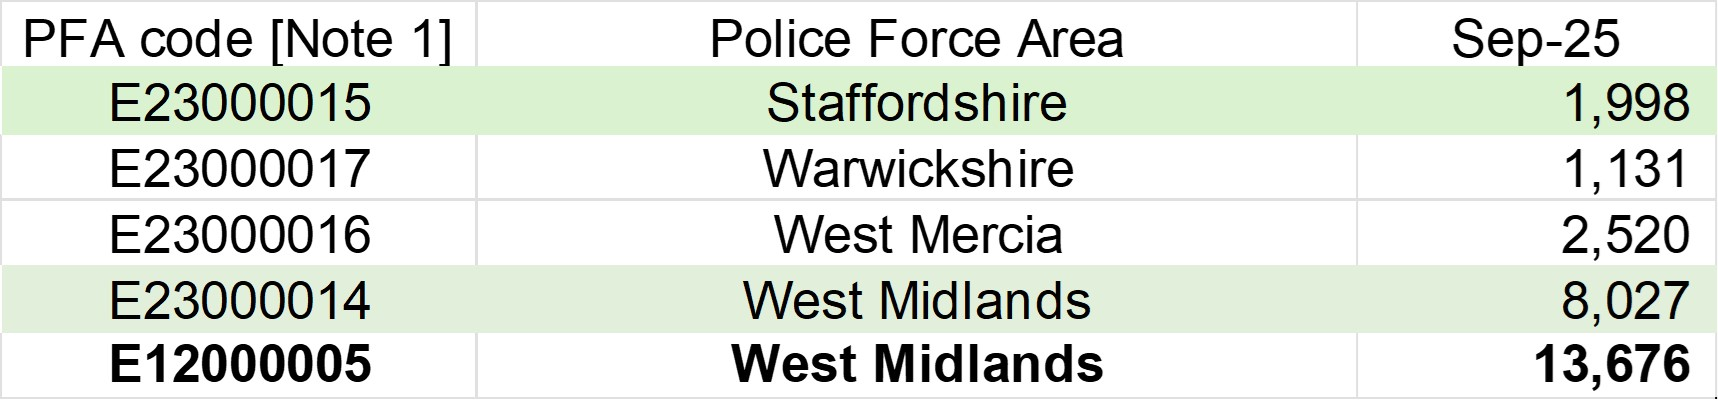



In [17]:
# Create DataFrame FTE from
FTE={
    'Reported by': ['West Midlands Police', 'Staffordshire Police'],
        'Police FTE': ['8027',	'1998']}
WorkForceFTE = pd.DataFrame(FTE)
WorkForceFTE

,Reported by,Police FTE
0,West Midlands Police,8027
1,Staffordshire Police,1998


*   IMD Decile and LSOA population data



In [18]:
# Read IMD Scores and LSOA population Excel file from Google drive
LSOAdata=pd.read_excel("/content/L7---Data-Analysis-and-Visualisation/Raw Data/2025_All_Ranks_Scores_Deciles_Population_Denominators.xlsx")
LSOAdata

,LSOA code (2021),LSOA name (2021),Local Authority District code (2024),Local Authority District name (2024),Index of Multiple Deprivation (IMD) Score,Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs),Income Score (rate),Income Rank (where 1 is most deprived),Income Decile (where 1 is most deprived 10% of LSOAs),...,Barriers to Housing and Services Score,Barriers to Housing and Services Rank (where 1 is most deprived),Barriers to Housing and Services Decile (where 1 is most deprived 10% of LSOAs),Living Environment Score,Living Environment Rank (where 1 is most deprived),Living Environment Decile (where 1 is most deprived 10% of LSOAs),Income Deprivation Affecting Children Index (IDACI) Score (rate),Income Deprivation Affecting Children Index (IDACI) Rank (where 1 is most deprived),Income Deprivation Affecting Children Index (IDACI) Decile (where 1 is most deprived 10% of LSOAs),Population LSOA
0,E01000001,City of London 001A,E09000001,City of London,8.742,26525,8,0.013,33730,10,...,10.950,29220,9,69.345,244,1,0.039,33304,10,1795
1,E01000002,City of London 001B,E09000001,City of London,4.722,31203,10,0.018,33669,10,...,6.703,32640,10,43.890,3702,2,0.076,31744,10,1671
2,E01000003,City of London 001C,E09000001,City of London,9.250,25913,8,0.107,25167,8,...,9.735,30400,10,41.163,4540,2,0.250,19647,6,1896
3,E01000005,City of London 001E,E09000001,City of London,19.884,14807,5,0.211,14836,5,...,24.623,11294,4,38.695,5403,2,0.459,9604,3,1737
4,E01000006,Barking and Dagenham 016A,E09000002,Barking and Dagenham,25.307,10917,4,0.343,7519,3,...,38.025,2745,1,29.616,9479,3,0.640,3669,2,1837
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33750,E01035758,Vale of White Horse 014H,E07000180,Vale of White Horse,7.945,27536,9,0.101,25934,8,...,15.321,23743,8,8.503,25435,8,0.192,23609,7,1154
33751,E01035759,Vale of White Horse 015G,E07000180,Vale of White Horse,7.622,27902,9,0.097,26440,8,...,23.669,12406,4,5.731,28626,9,0.162,25922,8,1640
33752,E01035760,Vale of White Horse 015H,E07000180,Vale of White Horse,7.946,27532,9,0.170,18127,6,...,10.074,30084,9,3.450,31180,10,0.206,22526,7,1693
33753,E01035761,Vale of White Horse 015I,E07000180,Vale of White Horse,6.682,28981,9,0.136,21596,7,...,19.265,18053,6,4.985,29506,9,0.212,22148,7,1690


In [19]:
# Keep columns needed at this stage from IMD and LSOA data
LSOAdataclean=LSOAdata.loc[:, [
    'LSOA code (2021)',
    'Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)',
    'Index of Multiple Deprivation (IMD) Score',
    'Income Score (rate)',
    'Employment Score (rate)',
    'Education, Skills and Training Score',
    'Health Deprivation and Disability Score',
    'Crime Score',
    'Barriers to Housing and Services Score',
    'Living Environment Score',
    'Income Deprivation Affecting Children Index (IDACI) Score (rate)',
    'Population LSOA'
    ]]
# rename column and prepare for merge
LSOAdataclean.rename(columns={'LSOA code (2021)':'LSOA code'}, inplace=True)
LSOAdataclean

,LSOA code,Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs),Index of Multiple Deprivation (IMD) Score,Income Score (rate),Employment Score (rate),"Education, Skills and Training Score",Health Deprivation and Disability Score,Crime Score,Barriers to Housing and Services Score,Living Environment Score,Income Deprivation Affecting Children Index (IDACI) Score (rate),Population LSOA
0,E01000001,8,8.742,0.013,0.014,0.004,-1.771,-2.220,10.950,69.345,0.039,1795
1,E01000002,10,4.722,0.018,0.010,0.169,-1.549,-2.277,6.703,43.890,0.076,1671
2,E01000003,8,9.250,0.107,0.064,3.269,-0.292,-0.765,9.735,41.163,0.250,1896
3,E01000005,5,19.884,0.211,0.104,17.852,0.436,-0.626,24.623,38.695,0.459,1737
4,E01000006,4,25.307,0.343,0.120,25.442,-0.372,-0.072,38.025,29.616,0.640,1837
...,...,...,...,...,...,...,...,...,...,...,...,...
33750,E01035758,9,7.945,0.101,0.074,10.893,-1.004,0.215,15.321,8.503,0.192,1154
33751,E01035759,9,7.622,0.097,0.081,7.528,-0.645,-1.047,23.669,5.731,0.162,1640
33752,E01035760,9,7.946,0.170,0.067,10.064,-0.743,-0.157,10.074,3.450,0.206,1693
33753,E01035761,9,6.682,0.136,0.054,8.482,-0.938,-0.566,19.265,4.985,0.212,1690


Inspect outliers outside scoring rules in IMD Decile and LSOA population data

In [20]:
# observe data for any outliers or potential data quality issue - none idenfitied
LSOAdataclean.describe().round(1)

,Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs),Index of Multiple Deprivation (IMD) Score,Income Score (rate),Employment Score (rate),"Education, Skills and Training Score",Health Deprivation and Disability Score,Crime Score,Barriers to Housing and Services Score,Living Environment Score,Income Deprivation Affecting Children Index (IDACI) Score (rate),Population LSOA
count,33755.0,33755.0,33755.0,33755.0,33755.0,33755.0,33755.0,33755.0,33755.0,33755.0,33755.0
mean,5.5,21.7,0.2,0.1,21.7,0.0,-0.0,21.7,21.7,0.3,1692.0
std,2.9,15.7,0.2,0.1,18.1,0.9,0.8,10.2,16.1,0.2,373.9
min,1.0,0.2,0.0,0.0,0.0,-3.1,-3.3,1.5,0.1,0.0,940.0
25%,3.0,9.7,0.1,0.1,7.5,-0.6,-0.6,14.1,8.6,0.2,1448.0
50%,6.0,17.4,0.2,0.1,16.5,-0.0,-0.0,20.1,17.8,0.3,1620.0
75%,8.0,29.7,0.3,0.2,31.2,0.6,0.6,27.6,31.7,0.5,1857.0
max,10.0,94.2,1.0,1.0,99.6,3.3,3.5,63.5,85.7,1.0,9512.0


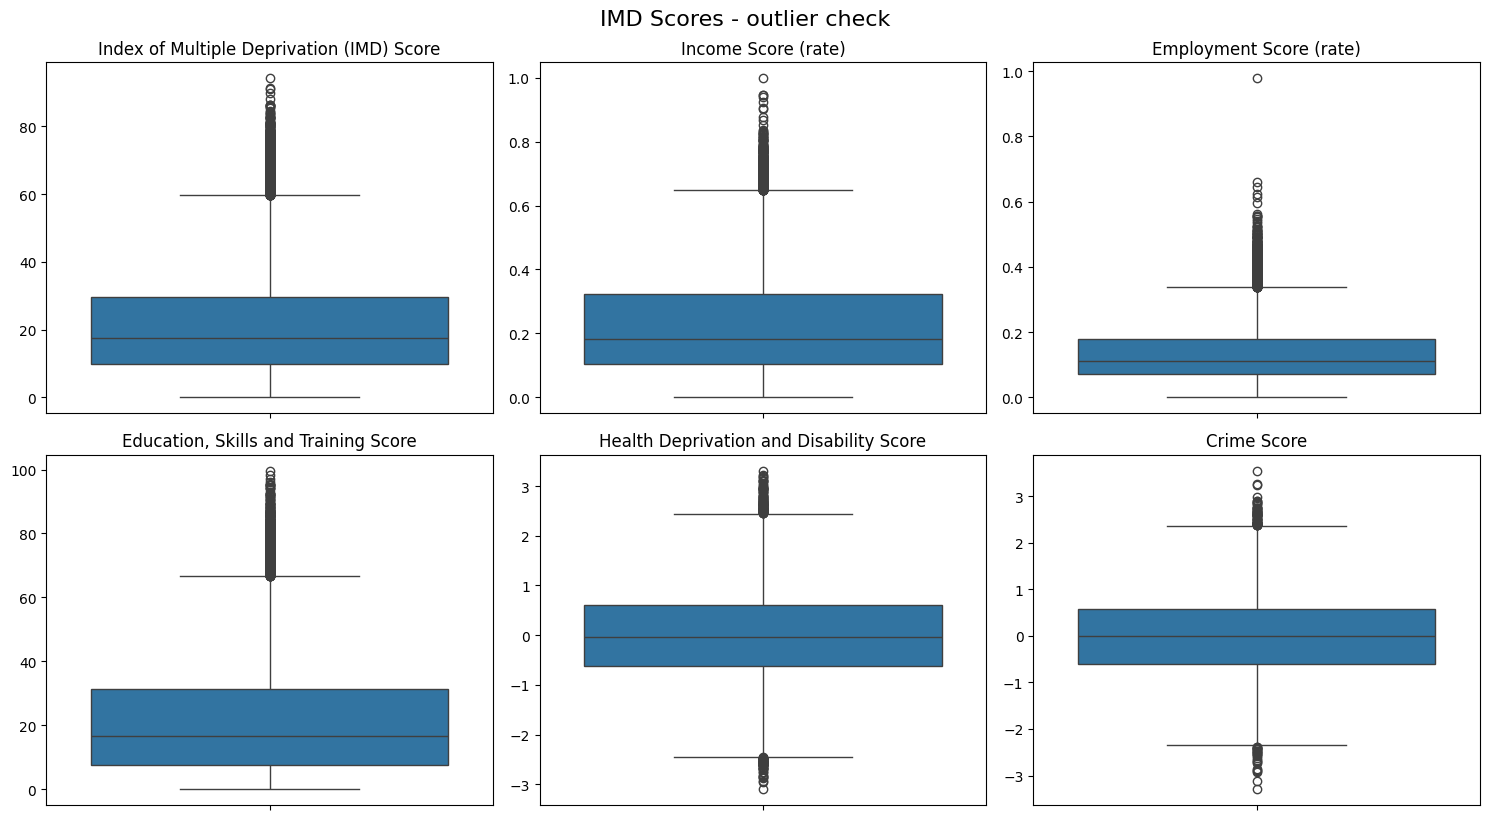

In [111]:
numerical_cols = [
    'Index of Multiple Deprivation (IMD) Score',
    'Income Score (rate)',
    'Employment Score (rate)',
    'Education, Skills and Training Score',
    'Health Deprivation and Disability Score',
    'Crime Score',
]

# Calculate the number of rows and columns for the subplots
num_plots = len(numerical_cols)
num_cols_subplot = 3 # You can adjust this number
num_rows_subplot = (num_plots + num_cols_subplot - 1) // num_cols_subplot

plt.figure(figsize=(num_cols_subplot * 5, num_rows_subplot * 4))

for i, col in enumerate(numerical_cols):
    plt.subplot(num_rows_subplot, num_cols_subplot, i + 1)
    sns.boxplot(y=LSOAdataclean[col])
    plt.title(col, fontsize=12)
    plt.ylabel('') # Hide y-label as title is descriptive
    plt.xlabel('')

plt.tight_layout()
plt.suptitle('IMD Scores - outlier check', y=1.02, fontsize=16)
plt.show()

#Merge data and final inspection

###Merge primary and supplementary data

In [22]:
#Merge LSOA data with Primary data
DataMerge1=pd.merge(CleanData,LSOAdataclean,on='LSOA code',how='left')
#Merge workforce data
DataMerge=pd.merge(DataMerge1,WorkForceFTE,on='Reported by',how='left')
DataMerge

,Month,Reported by,Location,LSOA code,LSOA name,Crime type,Last outcome category,Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs),Index of Multiple Deprivation (IMD) Score,Income Score (rate),Employment Score (rate),"Education, Skills and Training Score",Health Deprivation and Disability Score,Crime Score,Barriers to Housing and Services Score,Living Environment Score,Income Deprivation Affecting Children Index (IDACI) Score (rate),Population LSOA,Police FTE
0,2025-05,Staffordshire Police,On or near Oxton Road,E01007325,Barnsley 007C,Violence and sexual offences,Status update unavailable,1.0,56.555,0.568,0.306,60.460,1.941,1.345,16.876,1.352,0.727,1651.0,1998
1,2025-05,Staffordshire Police,On or near Turf Pits Lane,E01009416,Birmingham 003A,Violence and sexual offences,Unable to prosecute suspect,10.0,5.092,0.089,0.063,1.496,-0.967,-1.011,21.332,7.066,0.113,2787.0,1998
2,2025-05,Staffordshire Police,On or near Hill Top Close,E01009227,Birmingham 013C,Violence and sexual offences,Status update unavailable,4.0,22.255,0.230,0.160,24.146,0.408,0.265,11.413,29.321,0.394,1641.0,1998
3,2025-05,Staffordshire Police,On or near Mount Road,E01029368,Cannock Chase 001A,Anti-social behaviour,Data not recorded,10.0,4.695,0.041,0.056,10.123,-0.432,-1.065,14.580,7.204,0.081,1176.0,1998
4,2025-05,Staffordshire Police,On or near Whitworth Lane,E01029368,Cannock Chase 001A,Other theft,Investigation complete; no suspect identified,10.0,4.695,0.041,0.056,10.123,-0.432,-1.065,14.580,7.204,0.081,1176.0,1998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
869242,2023-12,West Midlands Police,On or near Silver Birch Road,E01034315,Wolverhampton 035J,Violence and sexual offences,Unable to prosecute suspect,3.0,29.651,0.414,0.155,37.482,0.465,0.653,19.792,12.866,0.531,1313.0,8027
869243,2023-12,West Midlands Police,On or near Willcock Road,E01034315,Wolverhampton 035J,Violence and sexual offences,Unable to prosecute suspect,3.0,29.651,0.414,0.155,37.482,0.465,0.653,19.792,12.866,0.531,1313.0,8027
869244,2023-12,West Midlands Police,On or near Thompson Avenue,E01034315,Wolverhampton 035J,Violence and sexual offences,Unable to prosecute suspect,3.0,29.651,0.414,0.155,37.482,0.465,0.653,19.792,12.866,0.531,1313.0,8027
869245,2023-12,West Midlands Police,On or near Rowan Tree Drive,E01034315,Wolverhampton 035J,Violence and sexual offences,Unable to prosecute suspect,3.0,29.651,0.414,0.155,37.482,0.465,0.653,19.792,12.866,0.531,1313.0,8027


###Add a new column enable "Year on Year" comparision later

In [23]:
# change data type for Column "Month", assadd a new column 'Month Group'
DataMerge['Month'] = pd.to_datetime(DataMerge['Month'])
start_date = pd.to_datetime('2023-12')
end_date = pd.to_datetime('2024-11')
DataMerge['Month Group'] = DataMerge['Month'].apply(lambda x: 'first 12 months' if (x >= start_date and x <= end_date) else 'second 12 months')
DataMerge

,Month,Reported by,Location,LSOA code,LSOA name,Crime type,Last outcome category,Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs),Index of Multiple Deprivation (IMD) Score,Income Score (rate),Employment Score (rate),"Education, Skills and Training Score",Health Deprivation and Disability Score,Crime Score,Barriers to Housing and Services Score,Living Environment Score,Income Deprivation Affecting Children Index (IDACI) Score (rate),Population LSOA,Police FTE,Month Group
0,2025-05-01,Staffordshire Police,On or near Oxton Road,E01007325,Barnsley 007C,Violence and sexual offences,Status update unavailable,1.0,56.555,0.568,0.306,60.460,1.941,1.345,16.876,1.352,0.727,1651.0,1998,second 12 months
1,2025-05-01,Staffordshire Police,On or near Turf Pits Lane,E01009416,Birmingham 003A,Violence and sexual offences,Unable to prosecute suspect,10.0,5.092,0.089,0.063,1.496,-0.967,-1.011,21.332,7.066,0.113,2787.0,1998,second 12 months
2,2025-05-01,Staffordshire Police,On or near Hill Top Close,E01009227,Birmingham 013C,Violence and sexual offences,Status update unavailable,4.0,22.255,0.230,0.160,24.146,0.408,0.265,11.413,29.321,0.394,1641.0,1998,second 12 months
3,2025-05-01,Staffordshire Police,On or near Mount Road,E01029368,Cannock Chase 001A,Anti-social behaviour,Data not recorded,10.0,4.695,0.041,0.056,10.123,-0.432,-1.065,14.580,7.204,0.081,1176.0,1998,second 12 months
4,2025-05-01,Staffordshire Police,On or near Whitworth Lane,E01029368,Cannock Chase 001A,Other theft,Investigation complete; no suspect identified,10.0,4.695,0.041,0.056,10.123,-0.432,-1.065,14.580,7.204,0.081,1176.0,1998,second 12 months
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
869242,2023-12-01,West Midlands Police,On or near Silver Birch Road,E01034315,Wolverhampton 035J,Violence and sexual offences,Unable to prosecute suspect,3.0,29.651,0.414,0.155,37.482,0.465,0.653,19.792,12.866,0.531,1313.0,8027,first 12 months
869243,2023-12-01,West Midlands Police,On or near Willcock Road,E01034315,Wolverhampton 035J,Violence and sexual offences,Unable to prosecute suspect,3.0,29.651,0.414,0.155,37.482,0.465,0.653,19.792,12.866,0.531,1313.0,8027,first 12 months
869244,2023-12-01,West Midlands Police,On or near Thompson Avenue,E01034315,Wolverhampton 035J,Violence and sexual offences,Unable to prosecute suspect,3.0,29.651,0.414,0.155,37.482,0.465,0.653,19.792,12.866,0.531,1313.0,8027,first 12 months
869245,2023-12-01,West Midlands Police,On or near Rowan Tree Drive,E01034315,Wolverhampton 035J,Violence and sexual offences,Unable to prosecute suspect,3.0,29.651,0.414,0.155,37.482,0.465,0.653,19.792,12.866,0.531,1313.0,8027,first 12 months


#Data Analysis and Visualisation

##1. Overview of crime volume change Year on Year – West Midlands Police




####1.1 West Midlands Police report crime fell by 6.1% year on year. At the same time, Staffordshire Police saw increase

In [24]:
#| Table 1. Year on year change of total crime activities

# Data transformation, group before pivot
crime_counts = DataMerge.groupby(['Reported by','Month Group']).size().reset_index(name='CrimeCount')
crime_counts

#Pivot crime_counts table, use 'Month Group' as column headers
crime_counts_pivot = crime_counts.pivot_table(index='Reported by', columns='Month Group', values='CrimeCount').reset_index()
crime_counts_pivot.columns.name = None # Remove the 'Month Group' name

#Calculate variance of the first 12 months and second 12 months
crime_counts_pivot ['Variance %'] =(crime_counts_pivot['second 12 months']-crime_counts_pivot['first 12 months'])/crime_counts_pivot['first 12 months']*100
crime_counts_pivot ['Variance %'] = crime_counts_pivot['Variance %'].round(1)
crime_counts_pivot

,Reported by,first 12 months,second 12 months,Variance %
0,Staffordshire Police,99527.0,101612.0,2.1
1,West Midlands Police,344501.0,323607.0,-6.1


####1.1 How did crime activities change around public facilities

Most of crimes took place in public locations, below an overview of how they've changed in 24 months.

In [25]:
#| Table 2. West Midland Police’s top 10 locations with the highest number of crimes in the second 12 months

crime_counts_type_wmp = DataMerge.groupby(['Location','Month Group','Reported by']).size().reset_index(name='CrimeCount')
crime_counts_type_wmp
crime_counts_type_wmp=crime_counts_type_wmp[crime_counts_type_wmp['Reported by'] == 'West Midlands Police']
crime_counts_pivot2 = crime_counts_type_wmp.pivot_table(index='Location', columns='Month Group',values='CrimeCount').reset_index()
crime_counts_pivot2.columns.name = None # Remove the 'Month Group' column name

#Calculate variance of the first 12 months and second 12 months
crime_counts_pivot2 ['Variance %'] =(crime_counts_pivot2['second 12 months']-crime_counts_pivot2['first 12 months'])/crime_counts_pivot2['first 12 months']*100
crime_counts_pivot2 ['Variance %'] = crime_counts_pivot2['Variance %'].round(1)
crime_counts_pivot2.sort_values(by=["second 12 months"],ascending=False).head(10)


,Location,first 12 months,second 12 months,Variance %
13043,On or near Parking Area,16164.0,15585.0,-3.6
16438,On or near Supermarket,15568.0,14757.0,-5.2
13358,On or near Petrol Station,9582.0,8987.0,-6.2
15332,On or near Shopping Area,9464.0,8918.0,-5.8
8859,On or near Hospital,2815.0,2560.0,-9.1
15736,On or near Sports/Recreation Area,2134.0,2345.0,9.9
8392,On or near High Street,2074.0,2070.0,-0.2
12277,On or near Nightclub,2126.0,1705.0,-19.8
6766,On or near Further/Higher Educational Building,1833.0,1546.0,-15.7
12163,On or near New Street,1307.0,1344.0,2.8


#How likely to get away with punishment/Cost of Crime
##AntiSocial does not have outcome recorded

###Over 46% suspects could not be prosecuted as the top outcome of all from WMP.
###There are 7.7% and 13.8% of crimes did not have an outcome recorded for West Midlands and staffordshire police repectively, this could potentially skewed the insights slightly

In [79]:
Outcome=['Unable to prosecute suspect']
Police=['West Midlands Police']
filtered_data1 = DataMerge[DataMerge['Reported by'].isin(Police)]
filtered_data2 = DataMerge[DataMerge['Last outcome category'].isin(Outcome) & DataMerge['Reported by'].isin(Police)]

crime_counts_type1 = filtered_data1.groupby(['Crime type']).size().reset_index(name='CrimeCount')
crime_counts_type2 = filtered_data2.groupby(['Crime type']).size().reset_index(name='CrimeCount-Unproscuted')
unproscuted_rate=pd.merge(crime_counts_type1,crime_counts_type2,on='Crime type',how='left')
unproscuted_rate['unproscuted_rate%']=(unproscuted_rate['CrimeCount-Unproscuted']/unproscuted_rate['CrimeCount'].astype(float))*100
unproscuted_rate['unproscuted_rate%']=unproscuted_rate['unproscuted_rate%'].round(1)
unproscuted_rate.sort_values(by=["unproscuted_rate%"],ascending=False)

,Crime type,CrimeCount,CrimeCount-Unproscuted,unproscuted_rate%
13,Violence and sexual offences,266582,190512.0,71.5
8,Public order,37459,21911.0,58.5
5,Other crime,13209,7613.0,57.6
7,Possession of weapons,12946,5442.0,42.0
3,Criminal damage and arson,50311,20694.0,41.1
6,Other theft,41491,15802.0,38.1
10,Shoplifting,62492,21738.0,34.8
11,Theft from the person,5613,1772.0,31.6
9,Robbery,14162,4372.0,30.9
1,Bicycle theft,3822,938.0,24.5


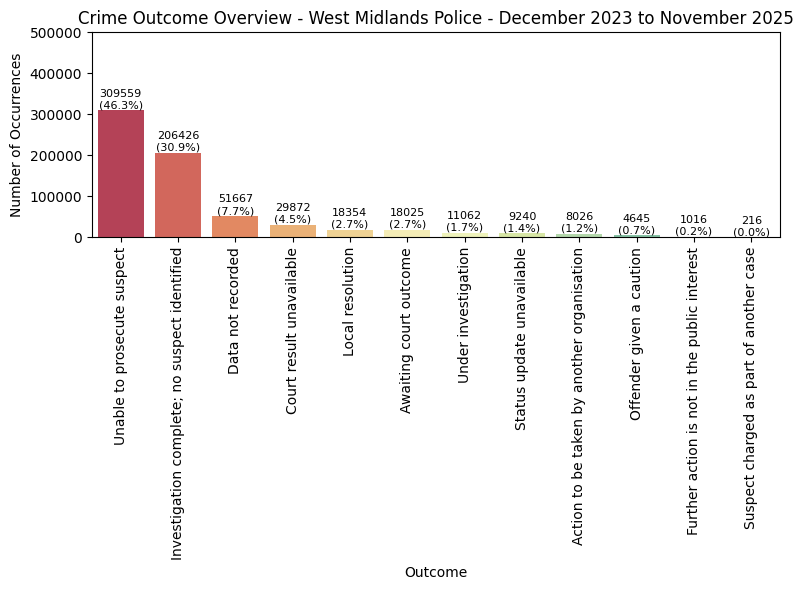

In [100]:
#| Plot 10. Crime outcomes %

chart1=CleanData[CleanData['Reported by'].isin(Police)]
outcome_counts = chart1['Last outcome category'].value_counts()
total_crimes = outcome_counts.sum()
outcome_percentages = (outcome_counts / total_crimes * 100).round(1)

plt.figure(figsize=(8, 6))
sns.barplot(x=outcome_counts.index, y=outcome_counts.values, hue=outcome_counts.index, palette='Spectral', legend=False)
plt.title('Crime Outcome Overview - West Midlands Police - December 2023 to November 2025')
plt.ylim(0, 500000)
plt.xlabel('Outcome')
plt.ylabel('Number of Occurrences')
plt.xticks(rotation=90)

# Add annotations for count and percentage
for index, value in enumerate(outcome_counts.values):
    percentage = outcome_percentages.iloc[index]
    plt.text(index, value + 50, f'{value}\n({percentage:.1f}%)', color='black', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

In [81]:
Outcome=['Unable to prosecute suspect']
Police=['West Midlands Police']

filtered_data_a = DataMerge[DataMerge['Reported by'].isin(Police)]
filtered_data_b= DataMerge[DataMerge['Last outcome category'].isin(Outcome) & DataMerge['Reported by'].isin(Police)]

crime_counts_type_a = filtered_data_a.groupby(['Crime type', 'Month Group']).size().reset_index(name='CrimeCount')
crime_counts_type_b = filtered_data_b.groupby(['Crime type', 'Month Group']).size().reset_index(name='CrimeCount-Unproscuted')

unproscuted_rate1 = pd.merge(crime_counts_type_a, crime_counts_type_b, on=['Crime type', 'Month Group'], how='left')
unproscuted_rate1['unproscuted_rate%'] = (unproscuted_rate1['CrimeCount-Unproscuted'] / unproscuted_rate1['CrimeCount'].astype(float)) * 100
unproscuted_rate1['unproscuted_rate%'] = unproscuted_rate1['unproscuted_rate%'].round(1)
unproscuted_rate1.sort_values(by=["Crime type"],ascending=True)


,Crime type,Month Group,CrimeCount,CrimeCount-Unproscuted,unproscuted_rate%
0,Anti-social behaviour,first 12 months,27784,NaN,NaN
1,Anti-social behaviour,second 12 months,23883,NaN,NaN
2,Bicycle theft,first 12 months,2011,538.0,26.8
3,Bicycle theft,second 12 months,1811,400.0,22.1
4,Burglary,first 12 months,17663,3469.0,19.6
5,Burglary,second 12 months,14559,2510.0,17.2
6,Criminal damage and arson,first 12 months,25711,11167.0,43.4
7,Criminal damage and arson,second 12 months,24600,9527.0,38.7
8,Drugs,first 12 months,7728,1830.0,23.7
9,Drugs,second 12 months,9277,1449.0,15.6


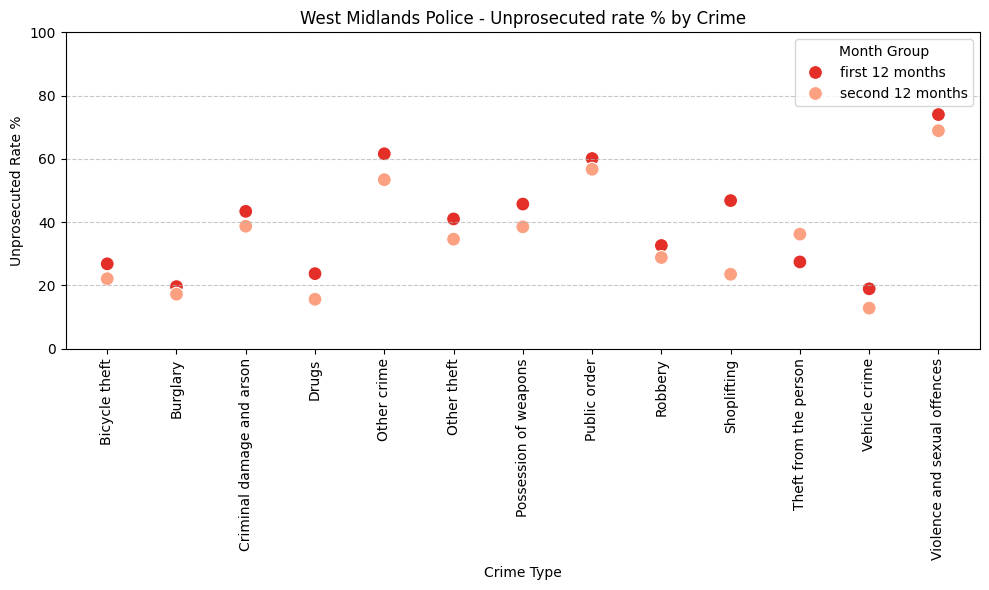

In [98]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Crime type', y='unproscuted_rate%', hue='Month Group', data=unproscuted_rate1, palette='Reds_r', s=100)
plt.title('West Midlands Police - Unprosecuted rate % by Crime')
plt.ylim(0, 100)
plt.xlabel('Crime Type')
plt.ylabel('Unprosecuted Rate %')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##2. Crime Hotspots – West Midlands Police
####2.1 LSOAs report most offenders




In [29]:
#| Table 3. Top 10 LSOAs with the highest crime activities in the second 12 months

crime_counts_type_wmp = DataMerge.groupby(['LSOA name','Month Group','Reported by']).size().reset_index(name='CrimeCount')
crime_counts_type_wmp
crime_counts_type_wmp=crime_counts_type_wmp[crime_counts_type_wmp['Reported by'] == 'West Midlands Police']
crime_counts_pivot1 = crime_counts_type_wmp.pivot_table(index='LSOA name', columns='Month Group',values='CrimeCount').reset_index()
crime_counts_pivot1.columns.name = None # Remove the 'Month Group' column name

crime_counts_pivot1 ['Variance %'] =(crime_counts_pivot1['second 12 months']-crime_counts_pivot1['first 12 months'])/crime_counts_pivot1['first 12 months']*100
crime_counts_pivot1 ['Variance %'] = crime_counts_pivot1['Variance %'].round(1)
crime_counts_pivot1.sort_values(by=["second 12 months"],ascending=False).head(10)

,LSOA name,first 12 months,second 12 months,Variance %
629,Birmingham 138A,5751.0,6246.0,8.6
1546,Walsall 030A,2442.0,2259.0,-7.5
809,Coventry 031E,2043.0,2241.0,9.7
614,Birmingham 135C,2330.0,1928.0,-17.3
236,Birmingham 050E,1863.0,1916.0,2.8
1695,Wolverhampton 020H,1964.0,1887.0,-3.9
237,Birmingham 050F,2124.0,1704.0,-19.8
810,Coventry 031F,1983.0,1670.0,-15.8
1314,Solihull 009A,1584.0,1373.0,-13.3
155,Birmingham 033F,1172.0,1232.0,5.1


####2.2 Hotspots in the most crime ridden LSOA - Birmingham 138A

In [30]:
#| Table 4. Top 10 locations reported highest crime activities in the second 12 months in “Birmingham 138A” LSOA

crime_counts_type_wmp = DataMerge.groupby(['LSOA name','Location','Month Group','Reported by']).size().reset_index(name='CrimeCount')
crime_counts_type_wmp
crime_counts_type_wmp=crime_counts_type_wmp[crime_counts_type_wmp['LSOA name'] == 'Birmingham 138A']
crime_counts_pivot3 = crime_counts_type_wmp.pivot_table(index='Location', columns='Month Group',values='CrimeCount').reset_index()
crime_counts_pivot3.columns.name = None # Remove the 'Month Group' column name

crime_counts_pivot3 ['Variance %'] =(crime_counts_pivot3['second 12 months']-crime_counts_pivot3['first 12 months'])/crime_counts_pivot3['first 12 months']*100
crime_counts_pivot3 ['Variance %'] = crime_counts_pivot3['Variance %'].round(1)
crime_counts_pivot3.sort_values(by=["second 12 months"],ascending=False).head(10)

,Location,first 12 months,second 12 months,Variance %
21,On or near Worcester Street,988.0,1259.0,27.4
10,On or near High Street,854.0,983.0,15.1
12,On or near New Street,768.0,825.0,7.4
17,On or near Supermarket,760.0,715.0,-5.9
16,On or near Shopping Area,733.0,649.0,-11.5
6,On or near Conference/Exhibition Centre,163.0,465.0,185.3
15,On or near Parking Area,385.0,204.5,-46.9
19,On or near Temple Street,144.0,147.0,2.1
5,On or near Colmore Row,109.0,105.0,-3.7
3,On or near Bennett'S Hill,80.0,104.0,30.0


In [31]:
#Join location data with Longitude and Latitude before plotting them on Google map
map_data1=crime_counts_pivot3.sort_values(by=["second 12 months"],ascending=False).head(10)
map_data1=map_data1.loc[:,['Location','Variance %','second 12 months']]
map_data2=CrimeData.loc[:,['Location','LSOA name','Longitude','Latitude']]
map_data2=map_data2[map_data2['LSOA name'] == 'Birmingham 138A']
map_data2=map_data2.drop_duplicates(subset=['Location','Longitude', 'Latitude'])
map_data=pd.merge(map_data1,map_data2,on='Location',how='left')
map_data.drop([5,6,9], inplace=True) # drop wrong coordinates
map_data

,Location,Variance %,second 12 months,LSOA name,Longitude,Latitude
0,On or near Worcester Street,27.4,1259.0,Birmingham 138A,-1.895744,52.478083
1,On or near High Street,15.1,983.0,Birmingham 138A,-1.894592,52.479565
2,On or near New Street,7.4,825.0,Birmingham 138A,-1.898553,52.479128
3,On or near Supermarket,-5.9,715.0,Birmingham 138A,-1.897764,52.482804
4,On or near Shopping Area,-11.5,649.0,Birmingham 138A,-1.898042,52.477374
7,On or near Conference/Exhibition Centre,185.3,465.0,Birmingham 138A,-1.903746,52.481497
8,On or near Parking Area,-46.9,204.5,Birmingham 138A,-1.902013,52.479266
10,On or near Temple Street,2.1,147.0,Birmingham 138A,-1.899273,52.479785
11,On or near Colmore Row,-3.7,105.0,Birmingham 138A,-1.899623,52.481430
12,On or near Bennett'S Hill,30.0,104.0,Birmingham 138A,-1.900392,52.480109


In [32]:
#| Plot 1. Top 10 Hotspots in “Birmingham 138A” LSOA plotted on Google map

from contextlib import redirect_stderr
map_plot = map_data.hvplot.points(
    x='Longitude',
    y='Latitude',
    s='second 12 months',
    color='Variance %',
    cmap='RdYlGn_r',
    geo=True,
    tiles='OSM', # OpenStreetMap tiles
    frame_width=800,
    frame_height=500,
    hover_cols=['Location','Variance %'], # Display Location, CrimeCount, Variance % on hover
    title='Top 10 Locations by Crime Activity - LSOA Birmingham 138A'
)
map_plot

:Overlay
   .WMTS.I   :WMTS   [Longitude,Latitude]
   .Points.I :Points   [Longitude,Latitude]   (Variance %,second 12 months,Location)

In [33]:
#| Plot 2. Year on year change by crime type in “Birmingham 138A” LSOA

crime_counts_type_wmp = DataMerge.groupby(['LSOA name','Crime type','Month Group','Reported by']).size().reset_index(name='CrimeCount')
crime_counts_type_wmp
crime_counts_type_wmp=crime_counts_type_wmp[crime_counts_type_wmp['LSOA name'] == 'Birmingham 138A']
crime_counts_pivot4 = crime_counts_type_wmp.pivot_table(index='Crime type', columns='Month Group',values='CrimeCount').reset_index()
crime_counts_pivot4.columns.name = None # Remove the 'Month Group' column name

crime_counts_pivot4 ['Variance %'] =(crime_counts_pivot4['second 12 months']-crime_counts_pivot4['first 12 months'])/crime_counts_pivot4['first 12 months']*100
crime_counts_pivot4 ['Variance %'] = crime_counts_pivot4['Variance %'].round(1)
crime_counts_pivot4.sort_values(by=["second 12 months"],ascending=False).head(10)

heatmap_data=crime_counts_pivot4.sort_values(by=["second 12 months"],ascending=False).head(10)
heatmap_data
heatmap_data=heatmap_data.sort_values(by=["Variance %"],ascending=False)

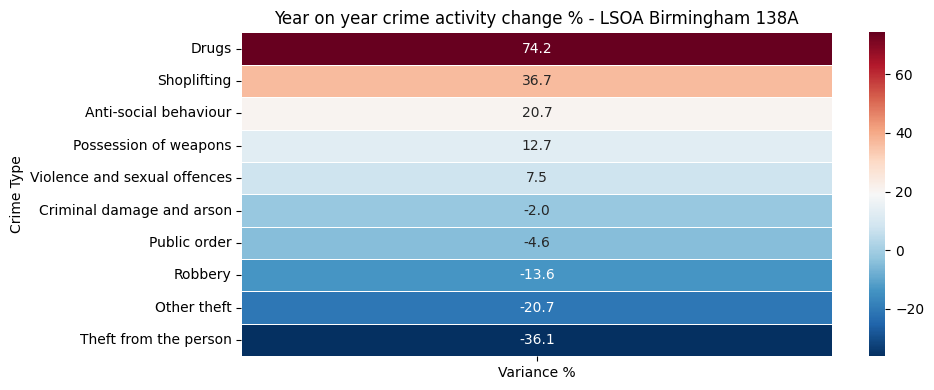

In [34]:
plt.figure(figsize=(10, 4))
sns.heatmap(heatmap_data.set_index('Crime type')[['Variance %']], annot=True, fmt=".1f", cmap="RdBu_r", linewidths=.5)
plt.title('Year on year crime activity change % - LSOA Birmingham 138A')
#plt.xlabel('Variance %')
plt.ylabel('Crime Type')
plt.tight_layout()
plt.show()

#3. West Midland Police (WMP) vs Staffordshire Police (SP)

In [101]:
crime_counts_lsoa = DataMerge.groupby(['LSOA name','Reported by','Population LSOA','Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)']).size().reset_index(name='CrimeCount')
crime_counts_lsoa['Weighted Crime/1000 population']=(crime_counts_lsoa['CrimeCount']/crime_counts_lsoa['Population LSOA'].astype(float))*1000/2 # 12 months not total 24 months
crime_counts_lsoa['Weighted Crime/1000 population']=crime_counts_lsoa['Weighted Crime/1000 population'].round(2)
crime_counts_lsoa

,LSOA name,Reported by,Population LSOA,Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs),CrimeCount,Weighted Crime/1000 population
0,Ashfield 001C,Staffordshire Police,1739.0,6.0,1,0.29
1,Ashfield 012B,Staffordshire Police,1390.0,5.0,1,0.36
2,Barking and Dagenham 007D,Staffordshire Police,1981.0,4.0,1,0.25
3,Barnsley 005E,Staffordshire Police,1844.0,8.0,1,0.27
4,Barnsley 007C,Staffordshire Police,1651.0,1.0,1,0.30
...,...,...,...,...,...,...
2941,Wyre Forest 001E,Staffordshire Police,1341.0,2.0,12,4.47
2942,Wyre Forest 001F,Staffordshire Police,2493.0,5.0,1,0.20
2943,Wyre Forest 005C,Staffordshire Police,1837.0,2.0,1,0.27
2944,Wyre Forest 011E,Staffordshire Police,1393.0,3.0,1,0.36


In [36]:
b=crime_counts_lsoa.pivot_table(index='Reported by',values="Population LSOA",aggfunc='sum')
c=crime_counts_lsoa.pivot_table(index='Reported by',values="CrimeCount",aggfunc='sum')
e=DataMerge.pivot_table(index='Reported by',values="Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)",aggfunc='mean')

WorkForceFTE,b,c,e
#merge and calculate weighted data by police
d=pd.merge(c,b,on='Reported by',how='left')
f=pd.merge(d,e,on='Reported by',how='left')
weighted_data=pd.merge(f,WorkForceFTE,on='Reported by',how='left')
weighted_data.rename(columns={'Population LSOA':'Service Population'}, inplace=True)

#Decide to use official population instead than LSOA aggregates from the merged report
weighted_data.replace({2013866.0:1130000,3022894.0:2900000}, inplace=True)

#Derive normalised crime data
weighted_data['Crime/1000 population/Year']=(weighted_data['CrimeCount']/weighted_data['Service Population'].astype(float))*1000/2
weighted_data['Crime/Police FTE/Year']=(weighted_data['CrimeCount']/weighted_data['Police FTE'].astype(float))/2
weighted_data['Population/FTE']=(weighted_data['Service Population']/weighted_data['Police FTE'].astype(float))

weighted_data.rename(columns={'Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)':'IMD Decile'}, inplace=True)
weighted_data.round(1)


,Reported by,CrimeCount,Service Population,IMD Decile,Police FTE,Crime/1000 population/Year,Crime/Police FTE/Year,Population/FTE
0,Staffordshire Police,200191,1130000.0,4.2,1998,88.6,50.1,565.6
1,West Midlands Police,668108,2900000.0,3.0,8027,115.2,41.6,361.3


#3.1 What is the role of high harm crimes?

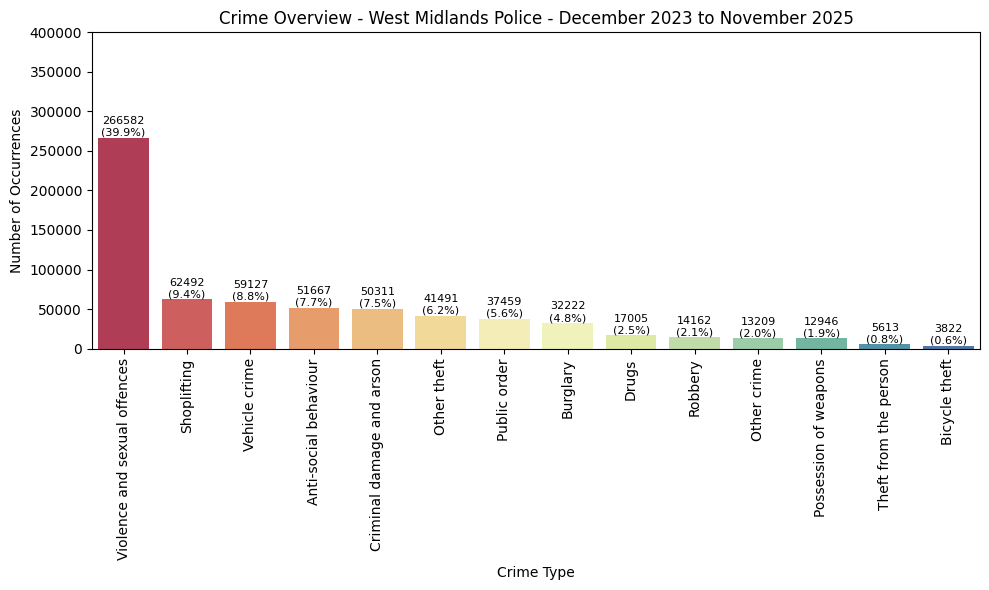

In [37]:
#Bar Chart with percentages of total % For Crime Types
Police=['West Midlands Police']
chart1=CleanData[CleanData['Reported by'].isin(Police)]
crime_type_counts = chart1['Crime type'].value_counts()
total_crimes = crime_type_counts.sum()
crime_type_percentages = (crime_type_counts / total_crimes * 100).round(1)

plt.figure(figsize=(10, 6))
sns.barplot(x=crime_type_counts.index, y=crime_type_counts.values, hue=crime_type_counts.index, palette='Spectral', legend=False)
plt.title('Crime Overview - West Midlands Police - December 2023 to November 2025')
plt.ylim(0, 400000)
plt.xlabel('Crime Type')
plt.ylabel('Number of Occurrences')
plt.xticks(rotation=90) # Rotate labels for better readability

# Add annotations for count and percentage
for index, value in enumerate(crime_type_counts.values):
    percentage = crime_type_percentages.iloc[index]
    plt.text(index, value + 50, f'{value}\n({percentage:.1f}%)', color='black', ha='center', va='bottom', fontsize=8)

# Adjust layout to prevent labels from being cut off
plt.tight_layout()
plt.show()

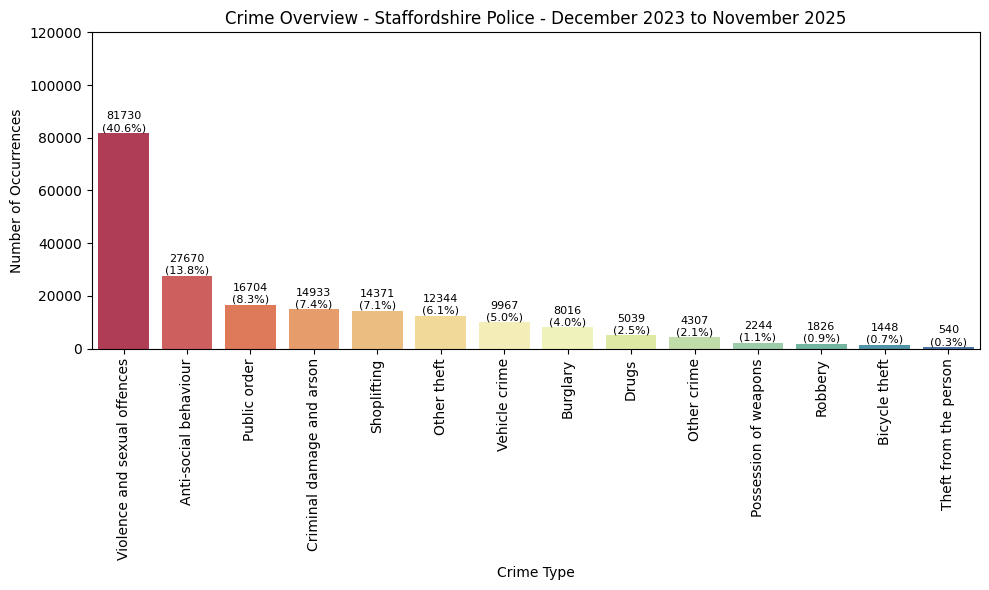

In [38]:
#Bar Chart with percentages of total % For Crime Types
Police1=['Staffordshire Police']
chart2=CleanData[CleanData['Reported by'].isin(Police1)]
crime_type_counts = chart2['Crime type'].value_counts()
total_crimes = crime_type_counts.sum()
crime_type_percentages = (crime_type_counts / total_crimes * 100).round(1)

plt.figure(figsize=(10, 6))
sns.barplot(x=crime_type_counts.index, y=crime_type_counts.values, hue=crime_type_counts.index, palette='Spectral', legend=False)
plt.title('Crime Overview - Staffordshire Police - December 2023 to November 2025')
plt.ylim(0, 120000)
plt.xlabel('Crime Type')
plt.ylabel('Number of Occurrences')
plt.xticks(rotation=90) # Rotate labels for better readability

# Add annotations for count and percentage
for index, value in enumerate(crime_type_counts.values):
    percentage = crime_type_percentages.iloc[index]
    plt.text(index, value + 50, f'{value}\n({percentage:.1f}%)', color='black', ha='center', va='bottom', fontsize=8)

# Adjust layout to prevent labels from being cut off
plt.tight_layout()
plt.show()

In [39]:
# West Midlands Police
crime_counts_type_wmp = DataMerge.groupby(['Crime type','Month Group','Reported by']).size().reset_index(name='CrimeCount')
crime_counts_type_wmp
crime_counts_type_wmp=crime_counts_type_wmp[crime_counts_type_wmp['Reported by'] == 'West Midlands Police']
crime_counts_pivot1 = crime_counts_type_wmp.pivot_table(index='Crime type', columns='Month Group',values='CrimeCount').reset_index()
crime_counts_pivot1.columns.name = None # Remove the 'Month Group' column name
crime_counts_pivot1 ['Variance %'] =(crime_counts_pivot1['second 12 months']-crime_counts_pivot1['first 12 months'])/crime_counts_pivot1['first 12 months']*100
crime_counts_pivot1 ['Variance %'] = crime_counts_pivot1['Variance %'].round(1)
crime_counts_pivot1.sort_values(by=["Variance %"],ascending=False)

,Crime type,first 12 months,second 12 months,Variance %
4,Drugs,7728.0,9277.0,20.0
10,Shoplifting,30229.0,32263.0,6.7
7,Possession of weapons,6356.0,6590.0,3.7
13,Violence and sexual offences,135136.0,131446.0,-2.7
3,Criminal damage and arson,25711.0,24600.0,-4.3
5,Other crime,6782.0,6427.0,-5.2
11,Theft from the person,2950.0,2663.0,-9.7
1,Bicycle theft,2011.0,1811.0,-9.9
8,Public order,19995.0,17464.0,-12.7
0,Anti-social behaviour,27784.0,23883.0,-14.0


In [40]:
# Staffordshire Police
crime_counts_type_sp = DataMerge.groupby(['Crime type','Month Group','Reported by']).size().reset_index(name='CrimeCount')
crime_counts_type_sp
crime_counts_type_sp=crime_counts_type_sp[crime_counts_type_sp['Reported by'] == 'Staffordshire Police']
crime_counts_pivot2 = crime_counts_type_sp.pivot_table(index='Crime type', columns='Month Group',values='CrimeCount').reset_index()
crime_counts_pivot2.columns.name = None # Remove the 'Month Group' column name
crime_counts_pivot2 ['Variance %'] =(crime_counts_pivot2['second 12 months']-crime_counts_pivot2['first 12 months'])/crime_counts_pivot2['first 12 months']*100
crime_counts_pivot2 ['Variance %'] = crime_counts_pivot2['Variance %'].round(1)
crime_counts_pivot2.sort_values(by=["Variance %"],ascending=False)


,Crime type,first 12 months,second 12 months,Variance %
4,Drugs,1926.0,3113.0,61.6
0,Anti-social behaviour,12414.0,15256.0,22.9
9,Robbery,826.0,1000.0,21.1
5,Other crime,1987.0,2320.0,16.8
7,Possession of weapons,1085.0,1159.0,6.8
8,Public order,8254.0,8450.0,2.4
13,Violence and sexual offences,40721.0,41009.0,0.7
10,Shoplifting,7380.0,6991.0,-5.3
3,Criminal damage and arson,7740.0,7193.0,-7.1
12,Vehicle crime,5209.0,4758.0,-8.7


In [41]:
#| Table 6. Year on year change by crime type - both Police forces

MergeCompare=pd.merge(crime_counts_pivot1,crime_counts_pivot2,on='Crime type',how='left')
MergeCompare=MergeCompare.loc[:, ['Crime type','Variance %_x','Variance %_y']]
MergeCompare.rename(columns={'Variance %_x':'Variance % West Midlands Police','Variance %_y':'Variance % Staffordshire Police'}, inplace=True)
MergeCompare

,Crime type,Variance % West Midlands Police,Variance % Staffordshire Police
0,Anti-social behaviour,-14.0,22.9
1,Bicycle theft,-9.9,-9.7
2,Burglary,-17.6,-20.6
3,Criminal damage and arson,-4.3,-7.1
4,Drugs,20.0,61.6
5,Other crime,-5.2,16.8
6,Other theft,-15.2,-9.0
7,Possession of weapons,3.7,6.8
8,Public order,-12.7,2.4
9,Robbery,-15.0,21.1


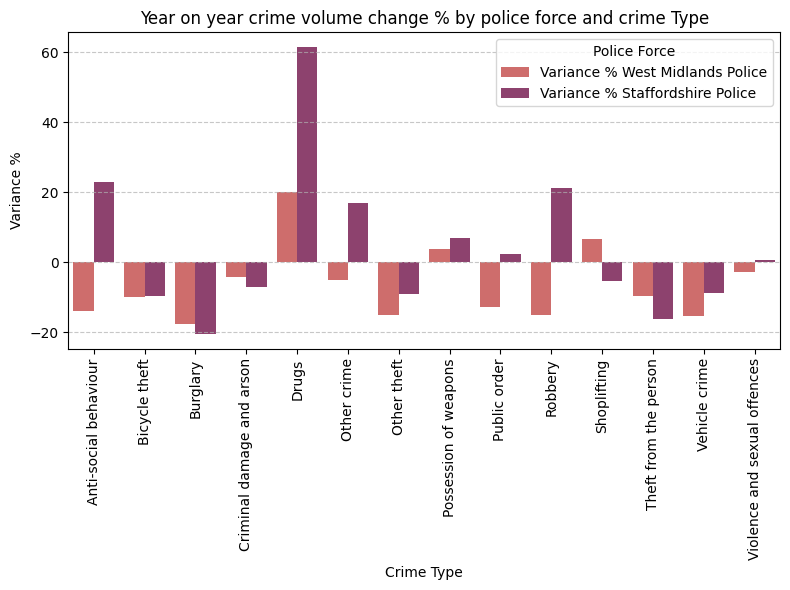

In [42]:
#|Plot 5. Year on year change by crime type - both police forces

MergeCompare_unpivoted = pd.melt(MergeCompare, id_vars=['Crime type'], value_vars=['Variance % West Midlands Police', 'Variance % Staffordshire Police'], var_name='Police Force', value_name='Variance %')
plt.figure(figsize=(8, 6))
sns.barplot(x='Crime type', y='Variance %', hue='Police Force', data=MergeCompare_unpivoted, palette = 'flare')#palette='viridis'
plt.title('Year on year crime volume change % by police force and crime Type')
plt.xlabel('Crime Type')
plt.ylabel('Variance %')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

####Create Radio Botton and pipeline for interactive plot

In [43]:
#Creat Radio button for interation with data
yaxis_police = pn.widgets.RadioButtonGroup(
    name='Count of Crime',
    options=['Anti-social behaviour','Bicycle theft','Burglary','Criminal damage and arson','Drugs','Other crime','Other theft','Possession of weapons','Public order','Robbery','Shoplifting','Theft from the person','Vehicle crime','Violence and sexual offences'],
    button_type='primary',
    button_style='outline'
    )
yaxis_police

RadioButtonGroup(button_style='outline', button_type='primary', name='Count of Crime', options=['Anti-social behaviour', ...], value='Anti-social behaviour')

In [44]:
#Prepare data for pipeline and make interactive
crime_over_time = DataMerge[['Reported by','Crime type','Month']].value_counts().reset_index(name='Count')
display(crime_over_time)
crime_over_time = crime_over_time.interactive()

,Reported by,Crime type,Month,Count
0,West Midlands Police,Violence and sexual offences,2024-05-01,12342
1,West Midlands Police,Violence and sexual offences,2025-07-01,12230
2,West Midlands Police,Violence and sexual offences,2024-07-01,12226
3,West Midlands Police,Violence and sexual offences,2025-06-01,11895
4,West Midlands Police,Violence and sexual offences,2024-06-01,11862
...,...,...,...,...
667,Staffordshire Police,Theft from the person,2025-06-01,18
668,Staffordshire Police,Theft from the person,2025-05-01,17
669,Staffordshire Police,Theft from the person,2024-03-01,15
670,Staffordshire Police,Theft from the person,2025-09-01,13


In [45]:
#crime_over_time_pivot_full = crime_over_time.pivot_table(index=['Month', 'Crime type'], columns='Reported by', values='Count').reset_index()
crime_over_time_pivot_full = crime_over_time.pivot_table(index=['Month', 'Reported by'], columns='Crime type', values='Count').reset_index()
crime_over_time_pivot_full.columns.name = None # Remove the column name for clarity
display(crime_over_time_pivot_full)

In [46]:
#Create interactive Pipeline
crime_pipeline =(
    crime_over_time_pivot_full
    .groupby(['Reported by','Month'])[yaxis_police].sum()
    .reset_index()
    .sort_values(by='Month')
    .reset_index(drop=True)
                 )
crime_pipeline

####Seasonal trend over 24 months - Interactive chart like dashboard, with radio buttons for filtering

In [47]:
#|Plot 6. Number of Drug crimes reported by month (December 2023 to November 2025)
crime_plot=crime_pipeline.hvplot(x='Month', by='Reported by', y=yaxis_police, line_width=2, width=1000, height=400, title ="Crime over time")
crime_plot

#3.2 What is the role of deprivation in crimes?



Correlations

In [48]:
#Calculate R = -0.75, indicate a correlation coefficient of 0.75 suggested negative strong correlation
correlation_deprivation = crime_counts_lsoa.groupby(['Reported by', 'Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)'])['Weighted Crime/1000 population'].mean().reset_index()
correlation_deprivation.rename(columns={'Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)':'IMD Decile'}, inplace=True)
#numerical_columns=['Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)','Weighted Crime/1000 population']
numerical_columns=['IMD Decile','Weighted Crime/1000 population']
print(correlation_deprivation[numerical_columns].corr().round(2))

                                IMD Decile  Weighted Crime/1000 population
IMD Decile                            1.00                           -0.75
Weighted Crime/1000 population       -0.75                            1.00


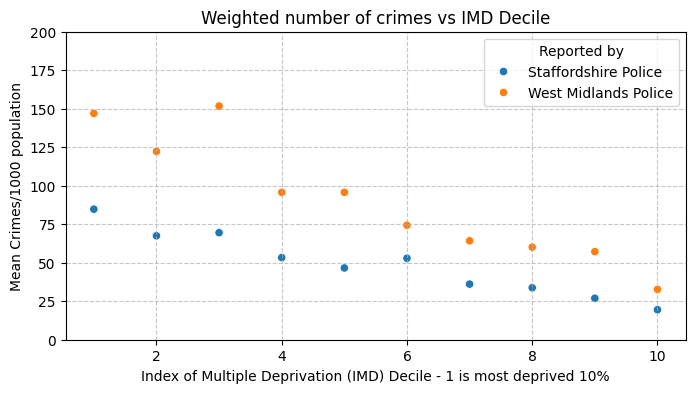

In [106]:
#| Plot 7. Correlation between crime per 1000 population and IMD decile – LSOA level

plt.figure(figsize=(8, 4))
sns.scatterplot(data=correlation_deprivation, x="IMD Decile", y="Weighted Crime/1000 population", hue="Reported by")
plt.title('Weighted number of crimes vs IMD Decile')
plt.xlabel('Index of Multiple Deprivation (IMD) Decile - 1 is most deprived 10%')
plt.ylabel('Mean Crimes/1000 population')
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(0, 200)
plt.show()

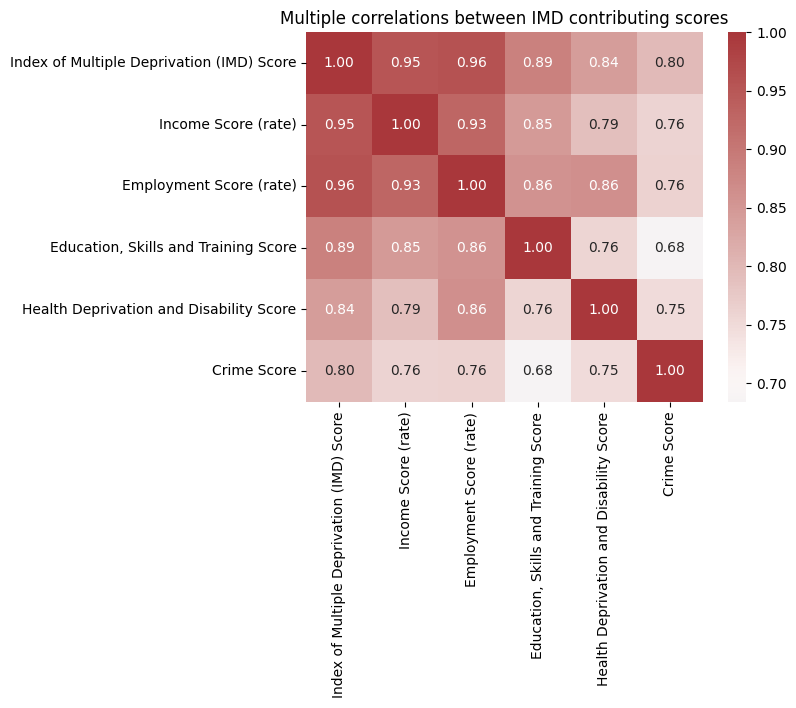

In [50]:
#| Plot 8. Correlation between IMD contributing scores

# Heatmap for correlation between several key scores contribute to IMD decile
num_cols = [
    'Index of Multiple Deprivation (IMD) Score',
    'Income Score (rate)',
    'Employment Score (rate)',
    'Education, Skills and Training Score',
    'Health Deprivation and Disability Score',
    'Crime Score',
    ]
sns.heatmap(LSOAdataclean[num_cols].corr(), annot=True, fmt=".2f", cmap="vlag", center=0.7)
plt.title('Multiple correlations between IMD contributing scores')
plt.show()

In [51]:
educatiom_imd_correlation=LSOAdata.loc[:, ['Index of Multiple Deprivation (IMD) Score','Education, Skills and Training Score']]
print(educatiom_imd_correlation.corr().round(2))

                                           Index of Multiple Deprivation (IMD) Score  \
Index of Multiple Deprivation (IMD) Score                                       1.00   
Education, Skills and Training Score                                            0.89   

                                           Education, Skills and Training Score  
Index of Multiple Deprivation (IMD) Score                                  0.89  
Education, Skills and Training Score                                       1.00  


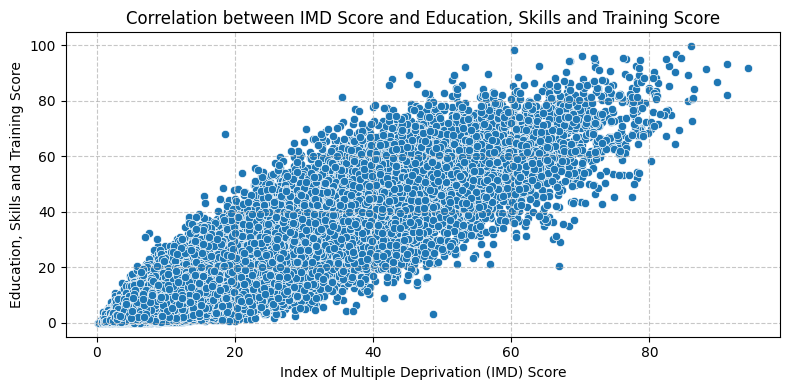

In [52]:
#| Plot 9. Scatter chart – Education scores vs IMD scores for WMP and SP (ONS)

plt.figure(figsize=(8, 4))
sns.scatterplot(data=educatiom_imd_correlation, x='Index of Multiple Deprivation (IMD) Score', y='Education, Skills and Training Score')
plt.title('Correlation between IMD Score and Education, Skills and Training Score')
plt.xlabel('Index of Multiple Deprivation (IMD) Score')
plt.ylabel('Education, Skills and Training Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()